# Домашнее задание 1. Обучение без учителя

## 1. Выбор и описание данных

Для работы выбран датасет **Mice Protein Expression** из UCI Machine Learning Repository: https://archive.ics.uci.edu/dataset/342/mice+protein+expression.

Датасет содержит измерения уровней экспрессии белков в коре головного мозга мышей. В эксперименте сравнивались контрольные мыши и мыши с трисомией, моделирующей синдром Дауна. Также учитывались тип поведения в эксперименте и лечение мемантином или физиологическим раствором.

- **77 числовых признаков**: уровни экспрессии белков и белковых модификаций
- **1080 измерений**
- в данных есть пропуски

Источник: Higuera, C., Gardiner, K., & Cios, K. (2015). *Mice Protein Expression* [Dataset]. UCI Machine Learning Repository. DOI: https://doi.org/10.24432/C50S3Z.

In [45]:
from pathlib import Path

import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", "{:.4f}".format)

In [46]:
DATA_PATH = Path("mice_protein_expression.xls")
if not DATA_PATH.exists():
    DATA_PATH = Path("1HW") / DATA_PATH


df = pd.read_excel(DATA_PATH)
df.head()

,MouseID,DYRK1A_N,ITSN1_N,BDNF_N,NR1_N,NR2A_N,pAKT_N,pBRAF_N,pCAMKII_N,pCREB_N,pELK_N,pERK_N,pJNK_N,PKCA_N,pMEK_N,...,pGSK3B_Tyr216_N,SHH_N,BAD_N,BCL2_N,pS6_N,pCFOS_N,SYP_N,H3AcK18_N,EGR1_N,H3MeK4_N,CaNA_N,Genotype,Treatment,Behavior,class
0,309_1,0.5036,0.7472,0.4302,2.8163,5.9902,0.2188,0.1776,2.3737,0.2322,1.7509,0.6879,0.3064,0.4027,0.2969,...,0.8316,0.1889,0.1227,NaN,0.1063,0.1083,0.4271,0.1148,0.1318,0.1282,1.6757,Control,Memantine,C/S,c-CS-m
1,309_2,0.5146,0.6891,0.4118,2.7895,5.6850,0.2116,0.1728,2.2921,0.2270,1.5964,0.6950,0.2991,0.3860,0.2813,...,0.8493,0.2004,0.1167,NaN,0.1066,0.1043,0.4416,0.1120,0.1351,0.1311,1.7436,Control,Memantine,C/S,c-CS-m
2,309_3,0.5092,0.7302,0.4183,2.6872,5.6221,0.2090,0.1757,2.2833,0.2302,1.5613,0.6773,0.2913,0.3810,0.2817,...,0.8467,0.1937,0.1185,NaN,0.1083,0.1062,0.4358,0.1119,0.1334,0.1274,1.9264,Control,Memantine,C/S,c-CS-m
3,309_4,0.4421,0.6171,0.3586,2.4669,4.9795,0.2229,0.1765,2.1523,0.2070,1.5951,0.5833,0.2967,0.3771,0.3138,...,0.8333,0.1921,0.1328,NaN,0.1032,0.1113,0.3917,0.1304,0.1474,0.1469,1.7006,Control,Memantine,C/S,c-CS-m
4,309_5,0.4349,0.6174,0.3588,2.3658,4.7187,0.2131,0.1736,2.1340,0.1922,1.5042,0.5510,0.2870,0.3635,0.2780,...,0.8787,0.2056,0.1300,NaN,0.1048,0.1107,0.4342,0.1185,0.1403,0.1484,1.8397,Control,Memantine,C/S,c-CS-m


In [47]:
df.shape

(1080, 82)

В локальном файле 1080 строк и 82 столбца. Из них:

- `MouseID` — идентификатор измерения;
- 77 столбцов с окончанием `_N` — числовые признаки экспрессии белков;
- `Genotype`, `Treatment`, `Behavior` — категориальные описания условий эксперимента;
- `class` — объединенная метка одной из восьми групп мышей.

Для кластеризации будем использовать только 77 числовых белковых признаков. Категориальные столбцы и `class` не будут подаваться в алгоритмы как признаки, но пригодятся позже для интерпретации кластеров и расчета внешних метрик.

In [48]:
id_column = "MouseID"
meta_columns = ["Genotype", "Treatment", "Behavior", "class"]
protein_features = [column for column in df.columns if column not in [id_column, *meta_columns]]

summary = pd.DataFrame(
    {
        "group": ["objects", "total_columns", "protein_features", "meta_columns"],
        "count": [len(df), df.shape[1], len(protein_features), len(meta_columns)],
    }
)
summary

,group,count
0,objects,1080
1,total_columns,82
2,protein_features,77
3,meta_columns,4


In [49]:
df[protein_features].describe().T.head(10)

,count,mean,std,min,25%,50%,75%,max
DYRK1A_N,1077.0000,0.4258,0.2494,0.1453,0.2881,0.3664,0.4877,2.5164
ITSN1_N,1077.0000,0.6171,0.2516,0.2454,0.4734,0.5658,0.6980,2.6027
BDNF_N,1077.0000,0.3191,0.0494,0.1152,0.2874,0.3166,0.3482,0.4972
NR1_N,1077.0000,2.2973,0.3473,1.3308,2.0574,2.2965,2.5285,3.7576
NR2A_N,1077.0000,3.8439,0.9331,1.7375,3.1557,3.7609,4.4400,8.4826
pAKT_N,1077.0000,0.2332,0.0416,0.0632,0.2058,0.2312,0.2573,0.5391
pBRAF_N,1077.0000,0.1818,0.0270,0.0640,0.1646,0.1823,0.1974,0.3171
pCAMKII_N,1077.0000,3.5371,1.2952,1.3440,2.4798,3.3265,4.4819,7.4641
pCREB_N,1077.0000,0.2126,0.0326,0.1128,0.1908,0.2106,0.2346,0.3062
pELK_N,1077.0000,1.4287,0.4669,0.4290,1.2037,1.3558,1.5613,6.1133


In [50]:
class_distribution = df["class"].value_counts().sort_index()
class_distribution

class
c-CS-m    150
c-CS-s    135
c-SC-m    150
c-SC-s    135
t-CS-m    135
t-CS-s    105
t-SC-m    135
t-SC-s    135
Name: count, dtype: int64

In [51]:
df[["Genotype", "Treatment", "Behavior", "class"]].nunique()

Genotype     2
Treatment    2
Behavior     2
class        8
dtype: int64

In [52]:
missing_summary = (
    df[protein_features]
    .isna()
    .sum()
    .sort_values(ascending=False)
    .rename("missing_count")
    .to_frame()
)
missing_summary["missing_share"] = missing_summary["missing_count"] / len(df)
missing_summary.query("missing_count > 0").head(15)

,missing_count,missing_share
BCL2_N,285,0.2639
H3MeK4_N,270,0.2500
BAD_N,213,0.1972
EGR1_N,210,0.1944
H3AcK18_N,180,0.1667
pCFOS_N,75,0.0694
ELK_N,18,0.0167
Bcatenin_N,18,0.0167
MEK_N,7,0.0065
ITSN1_N,3,0.0028


## 2. Разведочный анализ и подготовка данных

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid", context="notebook")

### 2.1. Базовые проверки

Сначала проверим типы столбцов, наличие дубликатов и соответствие набора числовых признаков ожидаемой структуре.

In [54]:
basic_checks = pd.DataFrame(
    {
        "check": [
            "rows",
            "columns",
            "protein_features",
            "duplicated_rows",
            "duplicated_mouse_id",
            "numeric_protein_features",
        ],
        "value": [
            len(df),
            df.shape[1],
            len(protein_features),
            df.duplicated().sum(),
            df[id_column].duplicated().sum(),
            df[protein_features].select_dtypes(include="number").shape[1],
        ],
    }
)
basic_checks

,check,value
0,rows,1080
1,columns,82
2,protein_features,77
3,duplicated_rows,0
4,duplicated_mouse_id,0
5,numeric_protein_features,77


In [55]:
df[[id_column, *meta_columns]].head()

,MouseID,Genotype,Treatment,Behavior,class
0,309_1,Control,Memantine,C/S,c-CS-m
1,309_2,Control,Memantine,C/S,c-CS-m
2,309_3,Control,Memantine,C/S,c-CS-m
3,309_4,Control,Memantine,C/S,c-CS-m
4,309_5,Control,Memantine,C/S,c-CS-m


### 2.2. Баланс экспериментальных групп

Посмотрим, насколько равномерно представлены известные группы. Эти столбцы не будут использоваться как признаки, но полезны для понимания данных и дальнейшей интерпретации кластеров.

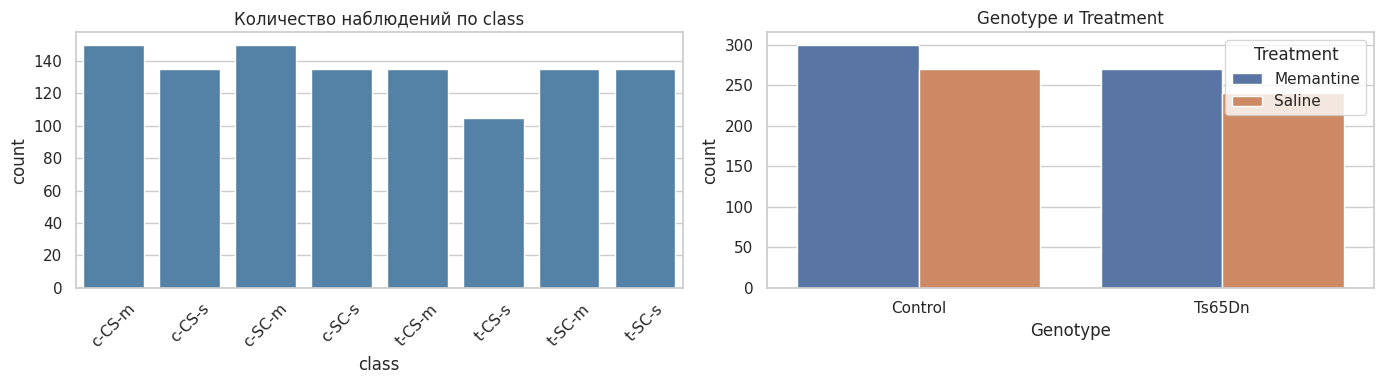

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.countplot(data=df, x="class", order=sorted(df["class"].unique()), ax=axes[0], color="steelblue")
axes[0].set_title("Количество наблюдений по class")
axes[0].set_xlabel("class")
axes[0].set_ylabel("count")
axes[0].tick_params(axis="x", rotation=45)

sns.countplot(data=df, x="Genotype", hue="Treatment", ax=axes[1])
axes[1].set_title("Genotype и Treatment")
axes[1].set_xlabel("Genotype")
axes[1].set_ylabel("count")

plt.tight_layout()

In [57]:
group_counts = (
    df.groupby(["Genotype", "Treatment", "Behavior", "class"], observed=True)
    .size()
    .rename("count")
    .reset_index()
    .sort_values("class")
)
group_counts

,Genotype,Treatment,Behavior,class,count
0,Control,Memantine,C/S,c-CS-m,150
2,Control,Saline,C/S,c-CS-s,135
1,Control,Memantine,S/C,c-SC-m,150
3,Control,Saline,S/C,c-SC-s,135
4,Ts65Dn,Memantine,C/S,t-CS-m,135
6,Ts65Dn,Saline,C/S,t-CS-s,105
5,Ts65Dn,Memantine,S/C,t-SC-m,135
7,Ts65Dn,Saline,S/C,t-SC-s,135


### 2.3. Пропуски

In [58]:
missing_features = missing_summary.query("missing_count > 0").copy()
missing_features["missing_percent"] = 100 * missing_features["missing_share"]
missing_features.head(20)

,missing_count,missing_share,missing_percent
BCL2_N,285,0.2639,26.3889
H3MeK4_N,270,0.2500,25.0000
BAD_N,213,0.1972,19.7222
EGR1_N,210,0.1944,19.4444
H3AcK18_N,180,0.1667,16.6667
pCFOS_N,75,0.0694,6.9444
ELK_N,18,0.0167,1.6667
Bcatenin_N,18,0.0167,1.6667
MEK_N,7,0.0065,0.6481
ITSN1_N,3,0.0028,0.2778


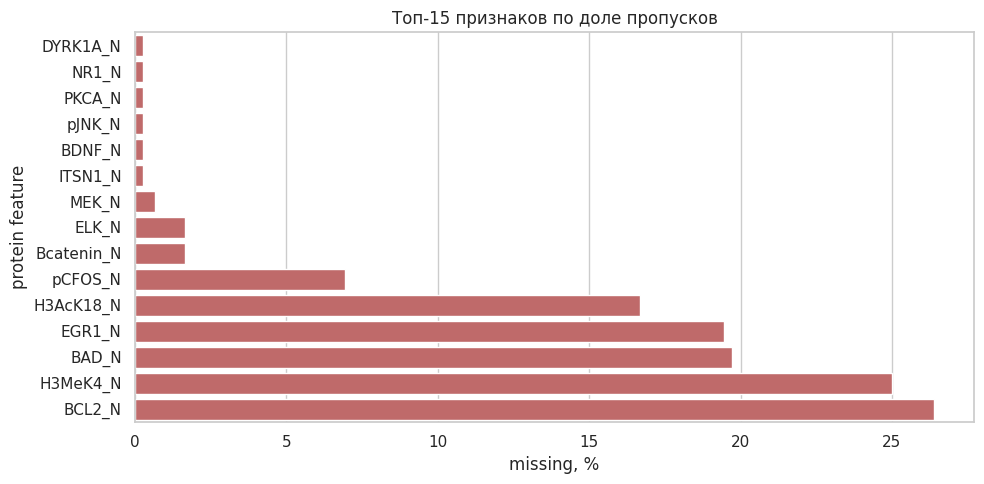

In [59]:
fig, ax = plt.subplots(figsize=(10, 5))
plot_data = missing_features.head(15).sort_values("missing_percent")
sns.barplot(data=plot_data, x="missing_percent", y=plot_data.index, ax=ax, color="indianred")
ax.set_title("Топ-15 признаков по доле пропусков")
ax.set_xlabel("missing, %")
ax.set_ylabel("protein feature")
plt.tight_layout()

In [60]:
missing_overview = pd.DataFrame(
    {
        "features_with_missing": [(missing_summary["missing_count"] > 0).sum()],
        "max_missing_count": [missing_summary["missing_count"].max()],
        "max_missing_share": [missing_summary["missing_share"].max()],
        "total_missing_values": [df[protein_features].isna().sum().sum()],
    }
)
missing_overview

,features_with_missing,max_missing_count,max_missing_share,total_missing_values
0,49,285,0.2639,1396


Пропуски сконцентрированы в ограниченном числе белков, но в некоторых признаках их доля заметная. Для дальнейшей кластеризации используем медианную импутацию.

### 2.4. Распределения и масштаб признаков

Белковые признаки имеют разные диапазоны и дисперсии. Для методов на расстояниях, особенно K-means и DBSCAN, это критично: признаки с большим масштабом могут искусственно доминировать в расстояниях.

In [61]:
feature_ranges = df[protein_features].agg(["min", "median", "max", "mean", "std"]).T
feature_ranges["range"] = feature_ranges["max"] - feature_ranges["min"]
feature_ranges.sort_values("range", ascending=False).head(10)

,min,median,max,mean,std,range
NR2A_N,1.7375,3.7609,8.4826,3.8439,0.9331,6.7450
pCAMKII_N,1.3440,3.3265,7.4641,3.5371,1.2952,6.1201
pELK_N,0.4290,1.3558,6.1133,1.4287,0.4669,5.6843
ERK_N,1.1318,2.4015,5.1984,2.4745,0.6534,4.0666
pERK_N,0.1492,0.4436,3.5667,0.5459,0.3453,3.4175
pPKCG_N,0.5988,1.6646,3.3820,1.7066,0.5784,2.7832
Bcatenin_N,1.1349,2.1148,3.6806,2.1465,0.4357,2.5457
pPKCAB_N,0.5678,1.3657,3.0614,1.5253,0.4818,2.4935
NR1_N,1.3308,2.2965,3.7576,2.2973,0.3473,2.4268
pNR2B_N,0.3016,1.5637,2.7240,1.5620,0.2707,2.4224


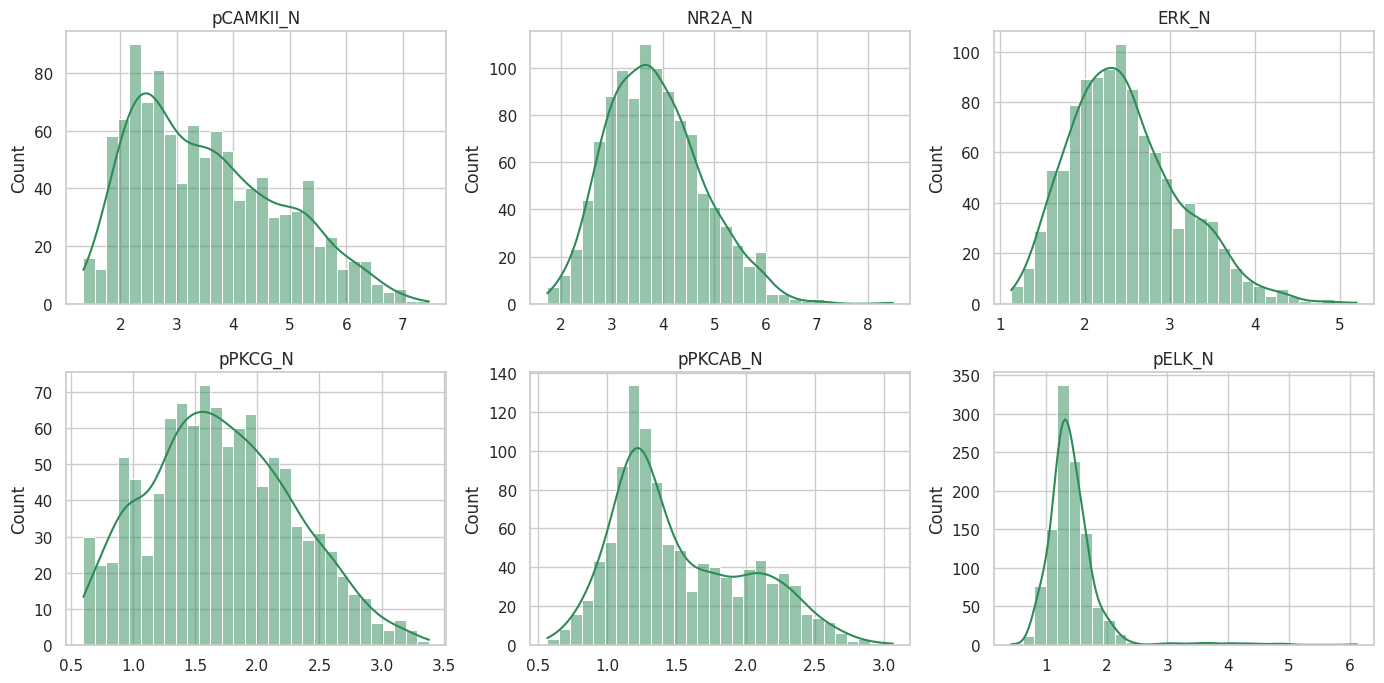

In [62]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
selected_features = feature_ranges.sort_values("std", ascending=False).head(6).index

for ax, feature in zip(axes.ravel(), selected_features):
    sns.histplot(df[feature], bins=30, kde=True, ax=ax, color="seagreen")
    ax.set_title(feature)
    ax.set_xlabel("")

plt.tight_layout()

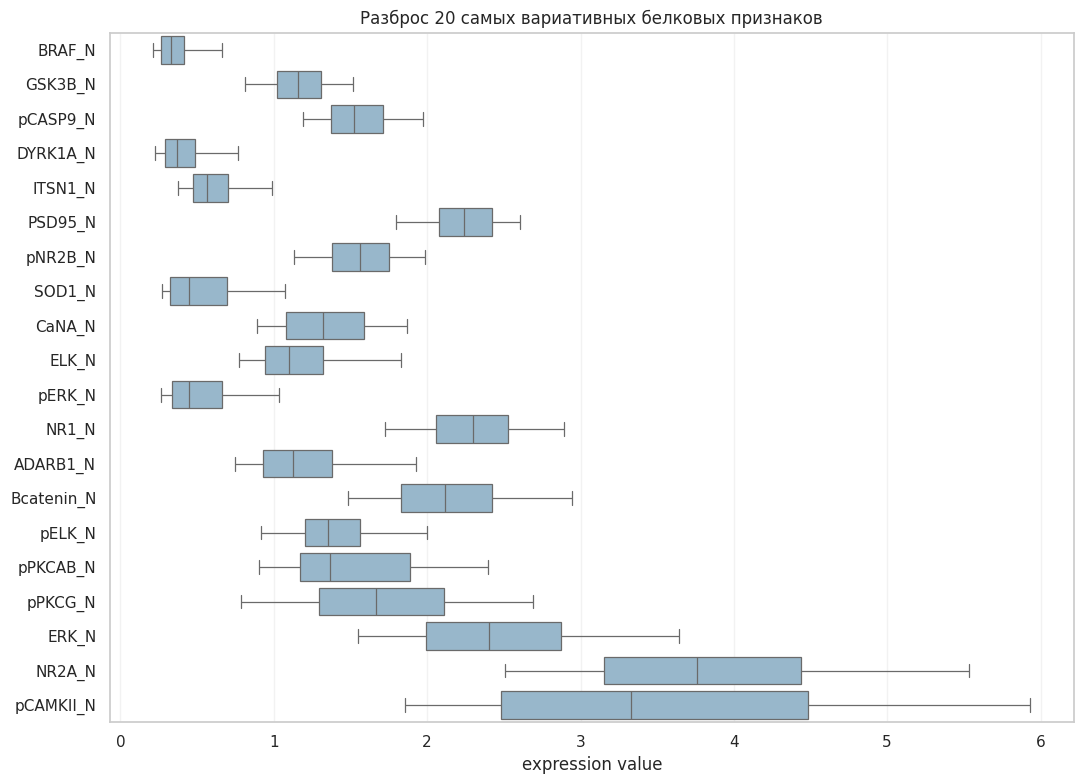

In [63]:
top_spread_features = feature_ranges.sort_values("std", ascending=False).head(20).index
spread_plot_data = (
    df[top_spread_features]
    .melt(var_name="protein", value_name="expression")
    .dropna()
)

fig, ax = plt.subplots(figsize=(11, 8))
sns.boxplot(
    data=spread_plot_data,
    x="expression",
    y="protein",
    order=list(reversed(top_spread_features)),
    ax=ax,
    color="#8fb9d4",
    linewidth=0.9,
    showfliers=False,
    whis=(5, 95),
)
ax.set_title("Разброс 20 самых вариативных белковых признаков")
ax.set_xlabel("expression value")
ax.set_ylabel("")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()

По исходным значениям видно, что признаки отличаются по масштабу и форме распределения. Поэтому после заполнения пропусков применяем стандартизацию: каждый белковый признак будет иметь среднее около 0 и стандартное отклонение около 1.

### 2.5. Подготовленная матрица для кластеризации

Сформируем две версии данных:

- `X_imputed` — белковые признаки после заполнения пропусков медианой;
- `X_scaled` — те же признаки после стандартизации, основная матрица для следующих моделей кластеризации.

Категориальные признаки и `class` в эти матрицы не входят.

In [64]:
X_raw = df[protein_features].copy()

imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()

X_imputed_array = imputer.fit_transform(X_raw)
X_scaled_array = scaler.fit_transform(X_imputed_array)

X_imputed = pd.DataFrame(X_imputed_array, columns=protein_features, index=df.index)
X_scaled = pd.DataFrame(X_scaled_array, columns=protein_features, index=df.index)

prepared_checks = pd.DataFrame(
    {
        "dataset": ["X_raw", "X_imputed", "X_scaled"],
        "rows": [X_raw.shape[0], X_imputed.shape[0], X_scaled.shape[0]],
        "columns": [X_raw.shape[1], X_imputed.shape[1], X_scaled.shape[1]],
        "missing_values": [
            X_raw.isna().sum().sum(),
            X_imputed.isna().sum().sum(),
            X_scaled.isna().sum().sum(),
        ],
    }
)
prepared_checks

,dataset,rows,columns,missing_values
0,X_raw,1080,77,1396
1,X_imputed,1080,77,0
2,X_scaled,1080,77,0


In [65]:
scaling_check = pd.DataFrame(
    {
        "dataset": ["before scaling", "after scaling"],
        "mean_abs_mean": [
            X_imputed.mean().abs().mean(),
            X_scaled.mean().abs().mean(),
        ],
        "mean_std": [
            X_imputed.std().mean(),
            X_scaled.std().mean(),
        ],
        "min_std": [
            X_imputed.std().min(),
            X_scaled.std().min(),
        ],
        "max_std": [
            X_imputed.std().max(),
            X_scaled.std().max(),
        ],
    }
)
scaling_check

,dataset,mean_abs_mean,mean_std,min_std,max_std
0,before scaling,0.6717,0.1577,0.0132,1.2934
1,after scaling,0.0000,1.0005,1.0005,1.0005


После преобразований получена числовая матрица `X_scaled` размера 1080 x 77 без пропусков. Она будет использоваться как основной вход для собственной реализации K-means и моделей из `sklearn`. Метки `class` сохраняются отдельно в `df["class"]` для последующего сравнения кластеров с известными экспериментальными группами.